<a href="https://colab.research.google.com/github/Nihcas001/data_analysis_using_Python/blob/main/05(B)_t-Test_and_One-Way_ANOVA%5COne_test_ANOVA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Import libraries
import pandas as pd
import numpy as np
from scipy import stats

In [ ]:
# Load the dataset
data = pd.read_csv("medicine_effectiveness_dataset.csv")

In [ ]:
# Display the dataset
data

,Patient_ID,Medicine,Pain_Reduction
0,1,Medicine_A,6.2
1,2,Medicine_A,5.8
2,3,Medicine_A,6.5
3,4,Medicine_A,5.9
4,5,Medicine_A,6.1
5,6,Medicine_A,6.7
6,7,Medicine_A,5.6
7,8,Medicine_A,6.3
8,9,Medicine_A,6.0
9,10,Medicine_A,6.4


In [ ]:
data.head()

,Patient_ID,Medicine,Pain_Reduction
0,1,Medicine_A,6.2
1,2,Medicine_A,5.8
2,3,Medicine_A,6.5
3,4,Medicine_A,5.9
4,5,Medicine_A,6.1


In [ ]:
data.tail()

,Patient_ID,Medicine,Pain_Reduction
40,41,Medicine_C,5.0
41,42,Medicine_C,5.3
42,43,Medicine_C,4.8
43,44,Medicine_C,5.2
44,45,Medicine_C,5.1


In [ ]:
data.shape

(45, 3)

In [ ]:
data.columns

Index(['Patient_ID', 'Medicine', 'Pain_Reduction'], dtype='object')

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45 entries, 0 to 44
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Patient_ID      45 non-null     int64  
 1   Medicine        45 non-null     object 
 2   Pain_Reduction  45 non-null     float64
dtypes: float64(1), int64(1), object(1)
memory usage: 1.2+ KB


In [ ]:
data.describe()

,Patient_ID,Pain_Reduction
count,45.000000,45.000000
mean,23.000000,6.124444
std,13.133926,0.890137
min,1.000000,4.700000
25%,12.000000,5.300000
50%,23.000000,6.100000
75%,34.000000,6.900000
max,45.000000,7.600000


### ***PART A — ONE-SAMPLE t-TEST***

**Step 4 — Select Medicine A**

We only need Medicine A for the one-sample t-test.

In [ ]:
medicine_a = data[data["Medicine"] == "Medicine_A"]
medicine_a

,Patient_ID,Medicine,Pain_Reduction
0,1,Medicine_A,6.2
1,2,Medicine_A,5.8
2,3,Medicine_A,6.5
3,4,Medicine_A,5.9
4,5,Medicine_A,6.1
5,6,Medicine_A,6.7
6,7,Medicine_A,5.6
7,8,Medicine_A,6.3
8,9,Medicine_A,6.0
9,10,Medicine_A,6.4


**Step 5 — Calculate Medicine A's mean**

In [ ]:
mean_a = medicine_a["Pain_Reduction"].mean()
print("Mean pain reduction:", mean_a)

Mean pain reduction: 6.133333333333332


In [ ]:
# Step 6 — Define the benchmark
# The company says that the benchmark effectiveness is 6.
benchmark = 6

So our test is:
```
Sample mean = 6.13
vs.
Benchmark = 6```

In [ ]:
# 12. Step 7 — Perform one-sample t-test
t_stat, p_value = stats.ttest_1samp(
    medicine_a["Pain_Reduction"],
    benchmark
)

print("t-statistic:", t_stat)
print("p-value:", p_value)

t-statistic: 1.5811388300841736
p-value: 0.1361687507038891


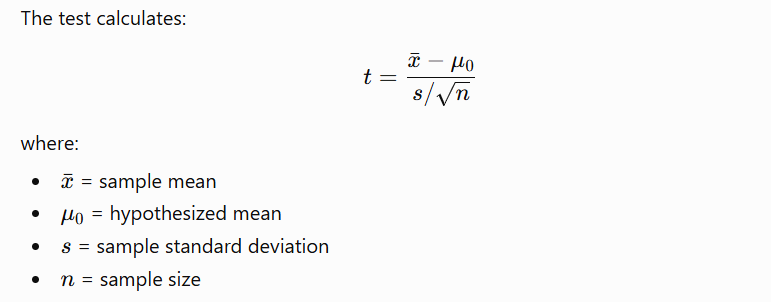

In [ ]:
# 13. Step 8 — Choose significance level
alpha = 0.05

# This means:We use a 5% significance level.

In [ ]:
# Now make the decision:
if p_value < alpha:
    print("Reject the Null Hypothesis")
else:
    print("Fail to Reject the Null Hypothesis")

Fail to Reject the Null Hypothesis


For this particular synthetic dataset, the p-value is expected to be greater than 0.05, so we fail to reject H₀.

**Interpretation**

The sample's average of approximately 6.13 is not sufficiently different from the benchmark of 6 at the 5% significance level.

### **PART B — ONE-WAY ANOVA**

Now comes the more interesting part.

Instead of asking:

Is Medicine A different from 6?

we ask:

**Are the three medicines different from each other?**

We have:

`Medicine A
Medicine B
Medicine C`

**What is ANOVA?**

**ANOVA = Analysis of Variance**

It is used to compare the means of three or more groups.

For example:
```
Medicine A → mean = 6.13
Medicine B → mean = 7.15
Medicine C → mean = 5.09
```

The question is:

**Are these differences large enough to be statistically significant?**

**Why not perform multiple t-tests?**

Suppose we have three medicines.

We could perform:

```
A vs B
A vs C
B vs C
```
using three separate t-tests.

But repeatedly conducting tests increases the chance of a **Type I error.**

ANOVA allows us to initially test all groups together.

### **Hypotheses for ANOVA**

**Null hypothesis**
$$ H_0:\mu_A=\mu_B=\mu_C $$

Meaning:

All three medicines have the same population mean effectiveness.

**Alternative hypothesis**

> H1:At least one mean is different

This distinction is extremely important.

ANOVA does not directly tell us which medicine is different.

It initially tells us whether there is evidence that at least one group mean differs.

In [ ]:
# 17. Step 9 — Separate the three groups
medicine_a = data[data["Medicine"] == "Medicine_A"]["Pain_Reduction"]
medicine_b = data[data["Medicine"] == "Medicine_B"]["Pain_Reduction"]
medicine_c = data[data["Medicine"] == "Medicine_C"]["Pain_Reduction"]

In [ ]:
# Step 10 — Calculate group means
print("Medicine A:", medicine_a.mean())
print("Medicine B:", medicine_b.mean())
print("Medicine C:", medicine_c.mean())

Medicine A: 6.133333333333332
Medicine B: 7.1466666666666665
Medicine C: 5.093333333333333


So visually we can already see differences.

But remember:

> Difference in sample means ≠ automatically statistically significant difference.

That's why we perform ANOVA.

In [ ]:
# Step 11 — Perform one-way ANOVA
# Using SciPy:
f_stat, p_value = stats.f_oneway(
    medicine_a,
    medicine_b,
    medicine_c
)

print("F-statistic:", f_stat)
print("p-value:", p_value)

F-statistic: 204.96460905349826
p-value: 2.146625448242097e-22


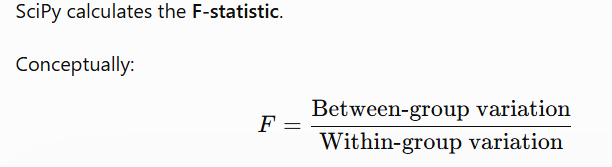

**What does F mean?**

Imagine the data like this:
```
Medicine A:     ● ● ● ● ●
                ↑
              mean

Medicine B:          ● ● ● ● ●
                     ↑
                   mean

Medicine C: ● ● ● ● ●
            ↑
          mean

```

ANOVA essentially compares:

**Variation between medicine groups**

with

**Variation within each medicine group**

If the groups have very different means while observations within each group are relatively close together, the F-statistic becomes large.


In [ ]:
# Step 12 — Make the ANOVA decision
alpha = 0.05

if p_value < alpha:
    print("Reject the Null Hypothesis")
else:
    print("Fail to Reject the Null Hypothesis")

Reject the Null Hypothesis


For our synthetic dataset, the p-value will be far below 0.05.

Therefore:

> **Reject H₀.**

**Interpretation**

There is statistically significant evidence that the mean pain-reduction scores are not all equal across the three medicines.

### **But which medicine is different?**

This is a very important concept for students.

ANOVA tells us:

> **At least one group differs.**

It does not tell us exactly which groups differ.

If ANOVA is significant, we can perform a post-hoc test, such as Tukey's HSD.

For example:

In [ ]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

tukey = pairwise_tukeyhsd(
    data["Pain_Reduction"],
    data["Medicine"],
    alpha=0.05
)
print(tukey)

    Multiple Comparison of Means - Tukey HSD, FWER=0.05    
  group1     group2   meandiff p-adj  lower   upper  reject
-----------------------------------------------------------
Medicine_A Medicine_B   1.0133   0.0  0.7669  1.2597   True
Medicine_A Medicine_C    -1.04   0.0 -1.2864 -0.7936   True
Medicine_B Medicine_C  -2.0533   0.0 -2.2997 -1.8069   True
-----------------------------------------------------------


This will compare:

```
Medicine A vs Medicine B
Medicine A vs Medicine C
Medicine B vs Medicine C
```

and identify which pairwise differences are statistically significant.